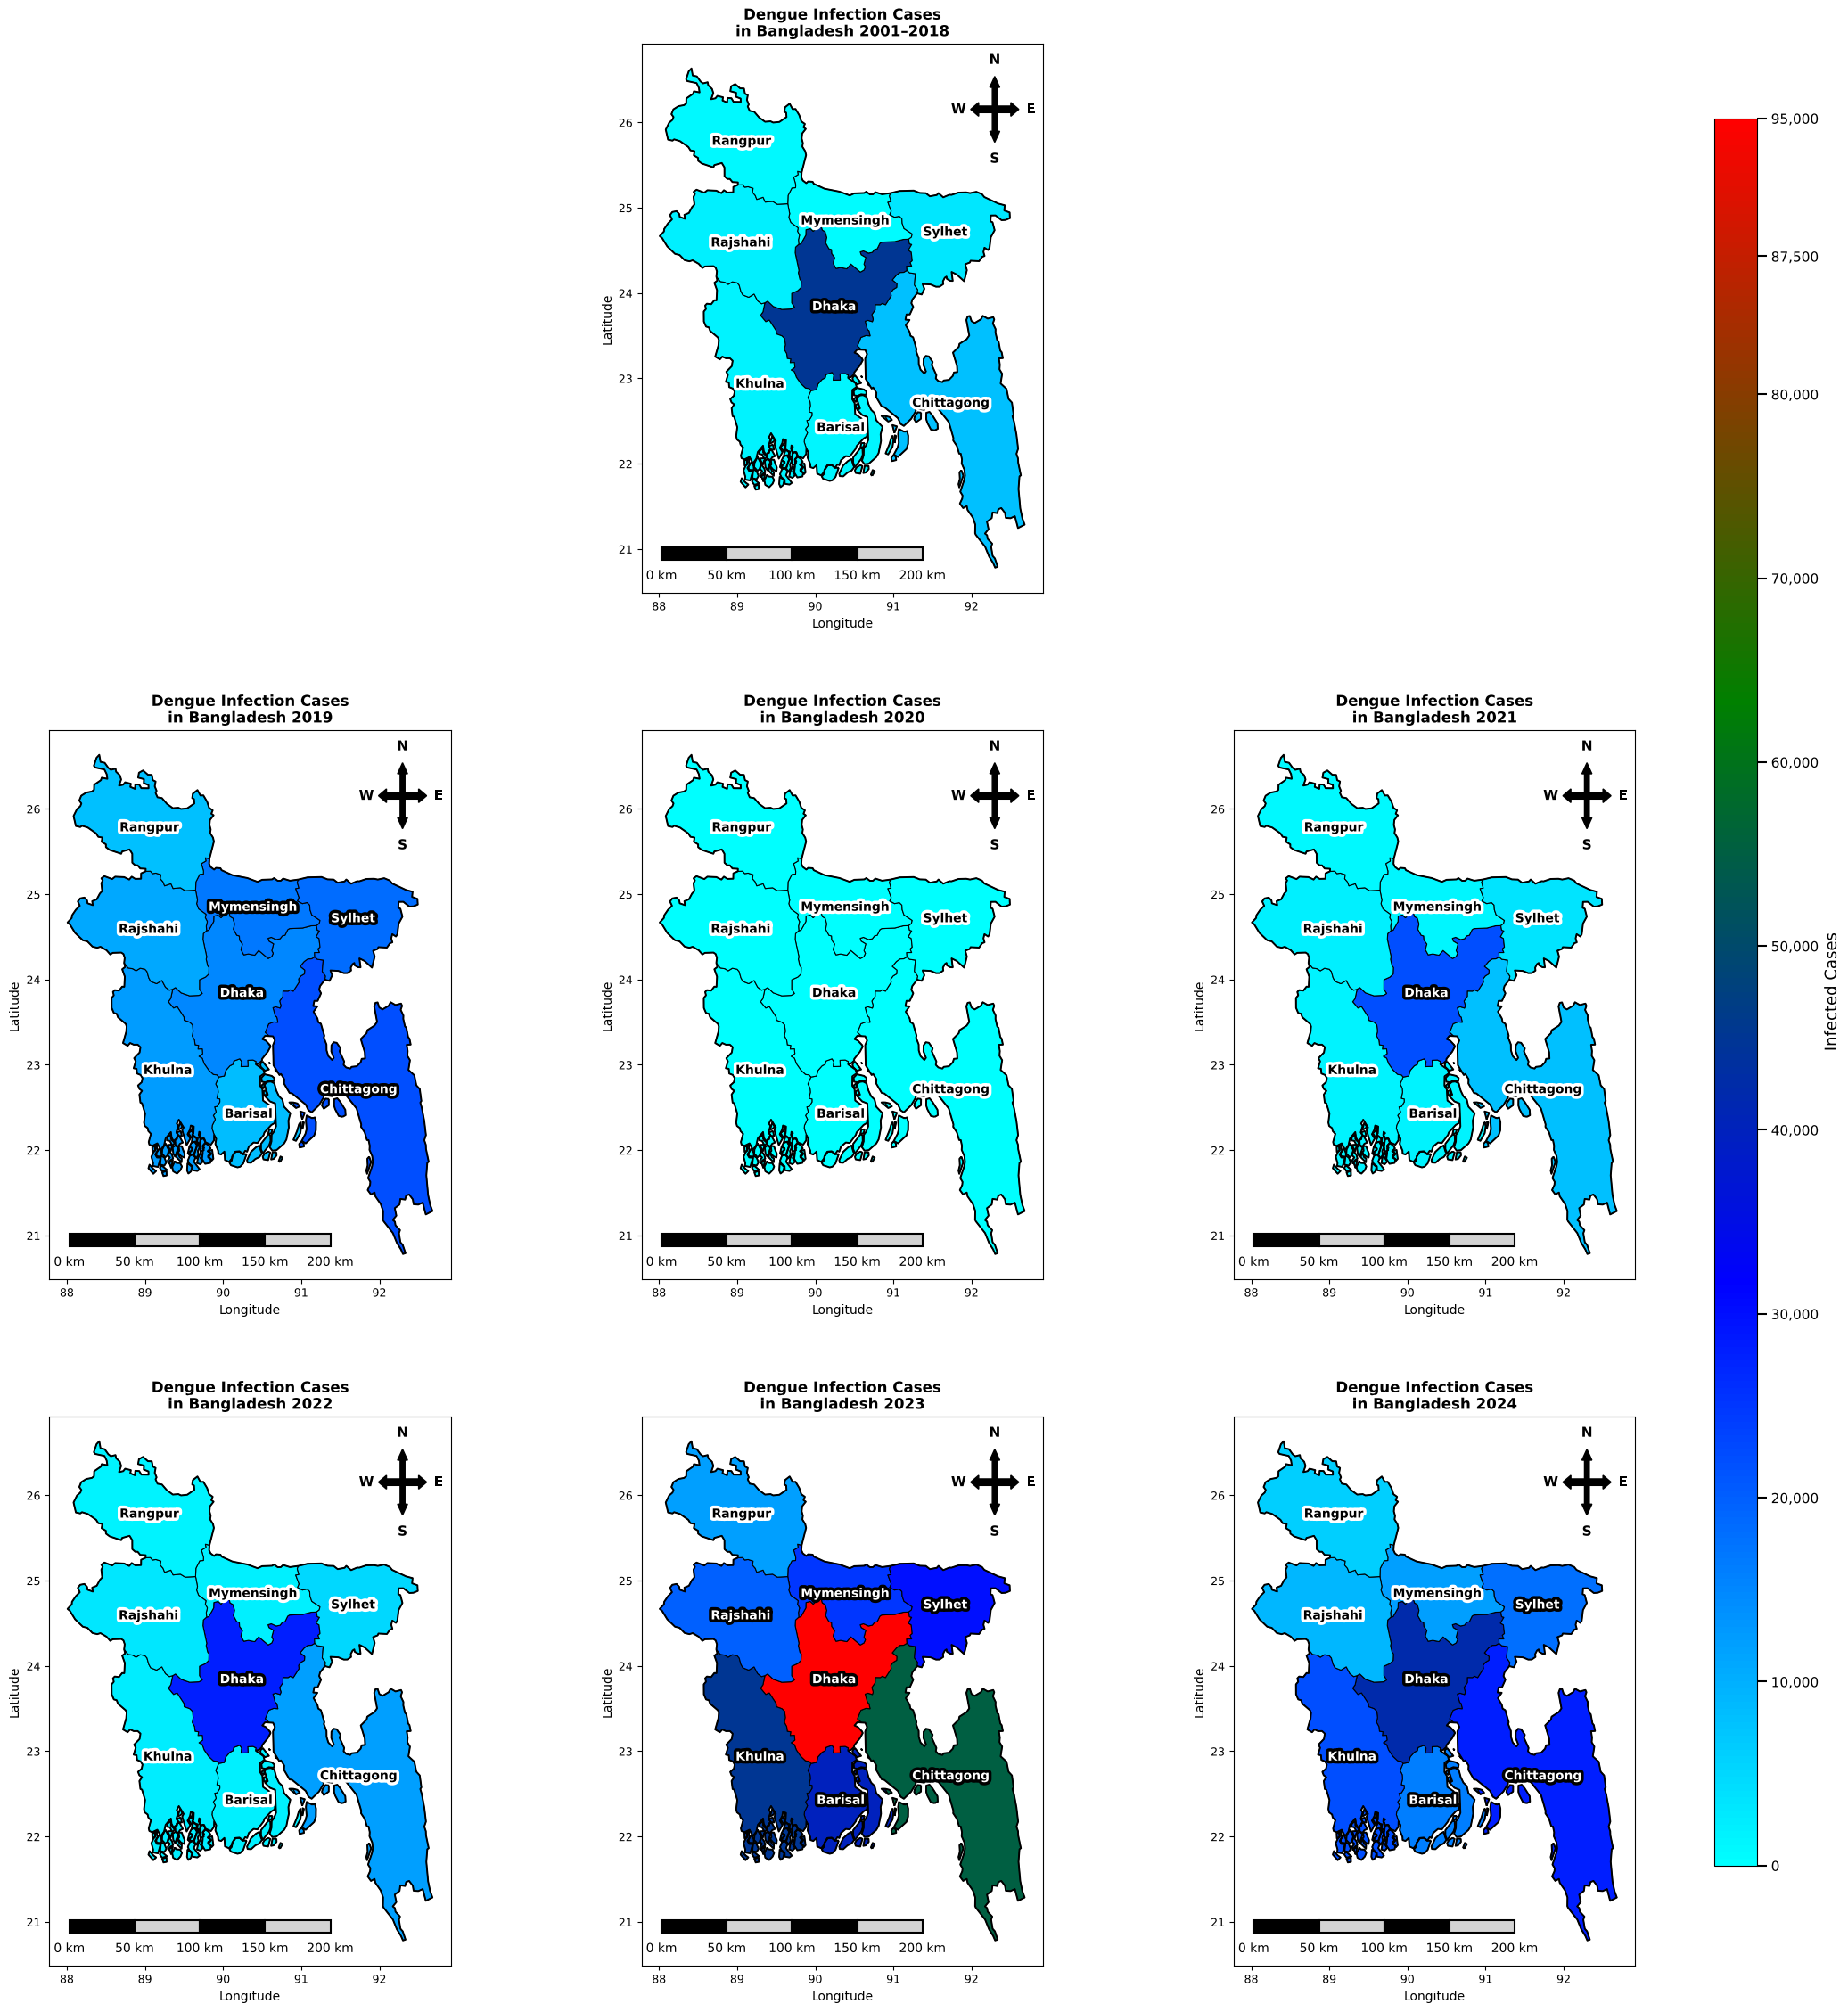

Saved: figure1_dengue_bangladesh.png


In [17]:
"""
Figure 1: Geographical distribution of dengue infection cases in Bangladesh (2001–2024)

Layout  : 1 wide panel for 2001-2018 (top row, full width)
          + 6 individual year panels for 2019-2024 (3 columns × 2 rows)
Colormap: Single continuous Blues gradient — light blue = low, dark blue = high
Borders : Black division borders + black country outline
Caption : Short explanatory note below the figure
"""

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrow
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd

# White halo applied to every text element for visibility over any background
STROKE = [pe.withStroke(linewidth=5, foreground="white")]

# ── Font sizes (single place to adjust) ───────────────────────────────────────
FS_TITLE      = 12   # panel title  — kept smaller so long titles fit in each column
FS_AXIS_LABEL = 10   # "Longitude" / "Latitude"
FS_TICK       = 9    # axis tick numbers
FS_DIV_LABEL  = 10   # division name on map
FS_COMPASS    = 11   # N / S / E / W letters
FS_SCALE      = 9    # scale bar km labels
FS_CBAR_LABEL = 13   # colorbar "Infected Cases"
FS_CBAR_TICK  = 11   # colorbar tick numbers
FS_CAPTION    = 10   # figure caption


def add_compass(ax, x=0.88, y=0.88, length=0.06):
    """Draw N/S/E/W intersecting arrows in the axes corner."""
    kw = dict(color='black', width=0.012, length_includes_head=True,
              head_width=0.025, head_length=0.02, transform=ax.transAxes,
              zorder=5)
    # N / S
    ax.add_patch(FancyArrow(x, y, 0,  length, **kw))
    ax.add_patch(FancyArrow(x, y, 0, -length, **kw))
    # E / W
    ax.add_patch(FancyArrow(x, y,  length, 0, **kw))
    ax.add_patch(FancyArrow(x, y, -length, 0, **kw))
    # Labels
    txt_kw = dict(ha='center', va='center', fontsize=FS_COMPASS,
                  fontweight='bold', transform=ax.transAxes, zorder=6,
                  path_effects=STROKE)
    ax.text(x,          y + length + 0.03, 'N', **txt_kw)
    ax.text(x,          y - length - 0.03, 'S', **txt_kw)
    ax.text(x + length + 0.03, y,          'E', **txt_kw)
    ax.text(x - length - 0.03, y,          'W', **txt_kw)


def add_scale_bar(ax, x=0.05, y=0.06, bar_len=0.65, bar_h=0.022,
                  n_segments=4, total_km=200):
    """Draw an alternating black/lightgray scale bar with km labels."""
    seg = bar_len / n_segments
    colors = ['black', 'lightgray'] * (n_segments // 2 + 1)

    for i in range(n_segments):
        ax.add_patch(mpatches.Rectangle(
            (x + i * seg, y), seg, bar_h,
            facecolor=colors[i], edgecolor='black', linewidth=1.5,
            transform=ax.transAxes, zorder=5
        ))

    # Labels below each segment boundary
    km_step = total_km // n_segments
    for i in range(n_segments + 1):
        ax.text(x + i * seg, y - 0.018,
                f'{i * km_step} km',
                ha='center', va='top', fontsize=FS_SCALE + 1, fontweight='normal',
                color='black', path_effects=STROKE,
                transform=ax.transAxes, zorder=6)



# ── 1. Load Bangladesh division shapefile ──────────────────────────────────────
# Download from: https://data.humdata.org/dataset/cod-ab-bgd
# File: bgd_admbnda_adm1_bbs_20201113.shp  (adjust path as needed)
shapefile_path = './geodata/small_bangladesh_geojson_adm1_8_divisions_bibhags.json'
gdf = gpd.read_file(shapefile_path)

# Normalise division name column (adjust 'ADM1_EN' to match your shapefile)
gdf["division"] = gdf["ADM1_EN"].str.strip()

# ── 2. Case data ───────────────────────────────────────────────────────────────
# Replace these values with your actual data.

data_2001_2018 = {
    "Dhaka":       45000,
    "Chittagong":   8000,
    "Sylhet":       3000,
    "Rajshahi":     2000,
    "Khulna":       1500,
    "Barisal":      1200,
    "Rangpur":       800,
    "Mymensingh":    600,
}

data_yearly = {
    2019: {"Dhaka": 15000, "Chittagong": 22000, "Sylhet": 18500,
           "Rajshahi": 11000, "Khulna": 12500, "Barisal": 8500,
           "Rangpur": 7800,  "Mymensingh": 17000},
    2020: {"Dhaka": 280,   "Chittagong": 310,   "Sylhet": 220,
           "Rajshahi": 155, "Khulna": 130,  "Barisal": 125,
           "Rangpur": 105,  "Mymensingh": 245},
    2021: {"Dhaka": 22000, "Chittagong": 8000,  "Sylhet": 3500,
           "Rajshahi": 2200, "Khulna": 1800, "Barisal": 1500,
           "Rangpur": 900,  "Mymensingh": 1200},
    2022: {"Dhaka": 28000, "Chittagong": 12000, "Sylhet": 5000,
           "Rajshahi": 3000, "Khulna": 2500, "Barisal": 2000,
           "Rangpur": 1500, "Mymensingh": 2000},
    2023: {"Dhaka": 95000, "Chittagong": 55000, "Sylhet": 30000,
           "Rajshahi": 20000, "Khulna": 45000, "Barisal": 40000,
           "Rangpur": 12000, "Mymensingh": 25000},
    2024: {"Dhaka": 42000, "Chittagong": 28000, "Sylhet": 18000,
           "Rajshahi": 9000, "Khulna": 22000, "Barisal": 16000,
           "Rangpur": 6000, "Mymensingh": 12000},
}

# ── 3. Shared colormap settings ────────────────────────────────────────────────
# RGBC gradient: Cyan (low) → Blue → Green → Red (high)
CMAP = mcolors.LinearSegmentedColormap.from_list(
    "RGBC", ["cyan", "blue", "green", "red"]
)
EDGE_COLOR  = "black"    # division border colour
EDGE_WIDTH  = 0.8        # border line width


def luminance(rgba):
    """Return perceived luminance (0=dark, 1=bright) for an RGBA colour tuple."""
    r, g, b = rgba[:3]
    return 0.299 * r + 0.587 * g + 0.114 * b


def plot_map(ax, gdf, case_data, title, norm):
    """Merge case data, plot choropleth with black borders using a shared norm."""
    df = pd.DataFrame(list(case_data.items()), columns=["division", "cases"])
    merged = gdf.merge(df, on="division", how="left")

    # Filled choropleth
    merged.plot(
        column="cases",
        cmap=CMAP,
        norm=norm,
        linewidth=EDGE_WIDTH,
        edgecolor=EDGE_COLOR,
        ax=ax,
        missing_kwds={"color": "lightgrey"},
    )

    # Country outline (draws the outer boundary on top for emphasis)
    gdf.dissolve().boundary.plot(ax=ax, color=EDGE_COLOR, linewidth=1.4)

    # Division labels — colour chosen dynamically based on fill brightness
    for _, row in merged.iterrows():
        if row.geometry is not None:
            cx = row.geometry.centroid.x
            cy = row.geometry.centroid.y

            # Map the division's case value to its fill colour
            val = row.get("cases", np.nan)
            if pd.isna(val):
                fill_rgba = (0.827, 0.827, 0.827, 1.0)   # lightgrey fallback
            else:
                fill_rgba = CMAP(norm(val))

            # White text on dark fills, black text on light fills
            txt_color = "white" if luminance(fill_rgba) < 0.45 else "black"
            # Stroke colour is the opposite, ensuring contrast either way
            stroke_color = "black" if txt_color == "white" else "white"
            stroke = [pe.withStroke(linewidth=5, foreground=stroke_color)]

            ax.annotate(
                row["division"],
                xy=(cx, cy),
                ha="center", va="center",
                fontsize=FS_DIV_LABEL, fontweight="bold",
                color=txt_color,
                path_effects=stroke,
            )

    # Split title onto two lines: "Dengue Infection Cases\nin Bangladesh YEAR"
    title_wrapped = title.replace(" in Bangladesh ", "\nin Bangladesh ")
    ax.set_title(title_wrapped, fontsize=FS_TITLE, fontweight="bold",
                 pad=6, linespacing=1.3).set_path_effects(STROKE)
    ax.set_xlabel("Longitude", fontsize=FS_AXIS_LABEL)
    ax.set_ylabel("Latitude", fontsize=FS_AXIS_LABEL)
    ax.tick_params(labelsize=FS_TICK)
    # Apply stroke to axis tick labels
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_path_effects(STROKE)

    # Compass and scale bar
    add_compass(ax)
    add_scale_bar(ax)


# ── 4. Compute global min/max across ALL datasets for a shared scale ───────────
all_values = list(data_2001_2018.values())
for yr_data in data_yearly.values():
    all_values.extend(yr_data.values())

global_vmin = 0                  # always start from zero
global_vmax = max(all_values)
shared_norm = mcolors.Normalize(vmin=global_vmin, vmax=global_vmax)

# ── 5. Figure layout ───────────────────────────────────────────────────────────
# Row 0: 2001-2018 panel centred in column 1 (middle), columns 0 and 2 left empty
# Rows 1-2: 3 × 2 grid of yearly panels (2019-2024)

fig = plt.figure(figsize=(24, 28))
gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.25,   # tighter vertical gap — reduces empty space between rows
    wspace=0.25,   # tighter horizontal gap — gives each panel more width for titles
)

# ── Panel A: 2001-2018 (row 0, centre column only) ────────────────────────────
ax_wide = fig.add_subplot(gs[0, 1])   # row 0, column 1 (middle)
plot_map(ax_wide, gdf, data_2001_2018,
         "Dengue Infection Cases in Bangladesh 2001–2018", shared_norm)

# ── Panels B-G: 2019-2024 (3 columns × 2 rows) ────────────────────────────────
years = list(data_yearly.keys())       # [2019, 2020, 2021, 2022, 2023, 2024]
positions = [
    (1, 0), (1, 1), (1, 2),           # 2019, 2020, 2021
    (2, 0), (2, 1), (2, 2),           # 2022, 2023, 2024
]

for year, (row, col) in zip(years, positions):
    ax = fig.add_subplot(gs[row, col])
    plot_map(ax, gdf, data_yearly[year],
             f"Dengue Infection Cases in Bangladesh {year}", shared_norm)

# ── Single shared colorbar on the right side of the figure ────────────────────
sm = cm.ScalarMappable(cmap=CMAP, norm=shared_norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])   # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)

# Build tick list: start from matplotlib's auto ticks, force vmin/vmax at ends,
# then insert one midpoint between every adjacent pair of ticks
auto_ticks = np.array(cbar.get_ticks())
# Ensure vmin and vmax are included
auto_ticks = np.unique(np.concatenate([[global_vmin], auto_ticks, [global_vmax]]))
# Insert midpoint between every adjacent pair
midpoints = (auto_ticks[:-1] + auto_ticks[1:]) / 2
all_ticks = np.unique(np.concatenate([auto_ticks, midpoints]))
# Clip strictly to [vmin, vmax] so no ticks fall outside the bar
all_ticks = all_ticks[(all_ticks >= global_vmin) & (all_ticks <= global_vmax)]

cbar.set_ticks(all_ticks)
cbar.set_ticklabels([f"{int(t):,}" for t in all_ticks])
cbar.set_label("Infected Cases", fontsize=FS_CBAR_LABEL)
cbar.ax.yaxis.label.set_path_effects(STROKE)
cbar.ax.tick_params(labelsize=FS_CBAR_TICK, length=8, width=1.5)
for lbl in cbar.ax.get_yticklabels():
    lbl.set_path_effects(STROKE)

# ── 5. Figure-level caption ────────────────────────────────────────────────────
# caption = (
#     "Figure 1: Geographical distribution of dengue infection cases across the eight divisions "
#     "of Bangladesh from 2001 to 2024. The top panel aggregates cumulative cases over 2001–2018; "
#     "individual panels show annual case counts for 2019–2024. "
#     "A continuous RGBC colour gradient is used in each panel: cyan indicates the fewest cases, "
#     "progressing through blue and green to red for the highest case counts, enabling intuitive "
#     "comparison of disease burden across divisions and time periods. "
#     "Black lines demarcate division boundaries."
# )
caption = ("")
fig.text(
    0.5, 0.01,
    caption,
    ha="center", va="bottom",
    fontsize=FS_CAPTION, style="italic",
    wrap=True,
)

plt.savefig("figure1_dengue_bangladesh.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figure1_dengue_bangladesh.png")

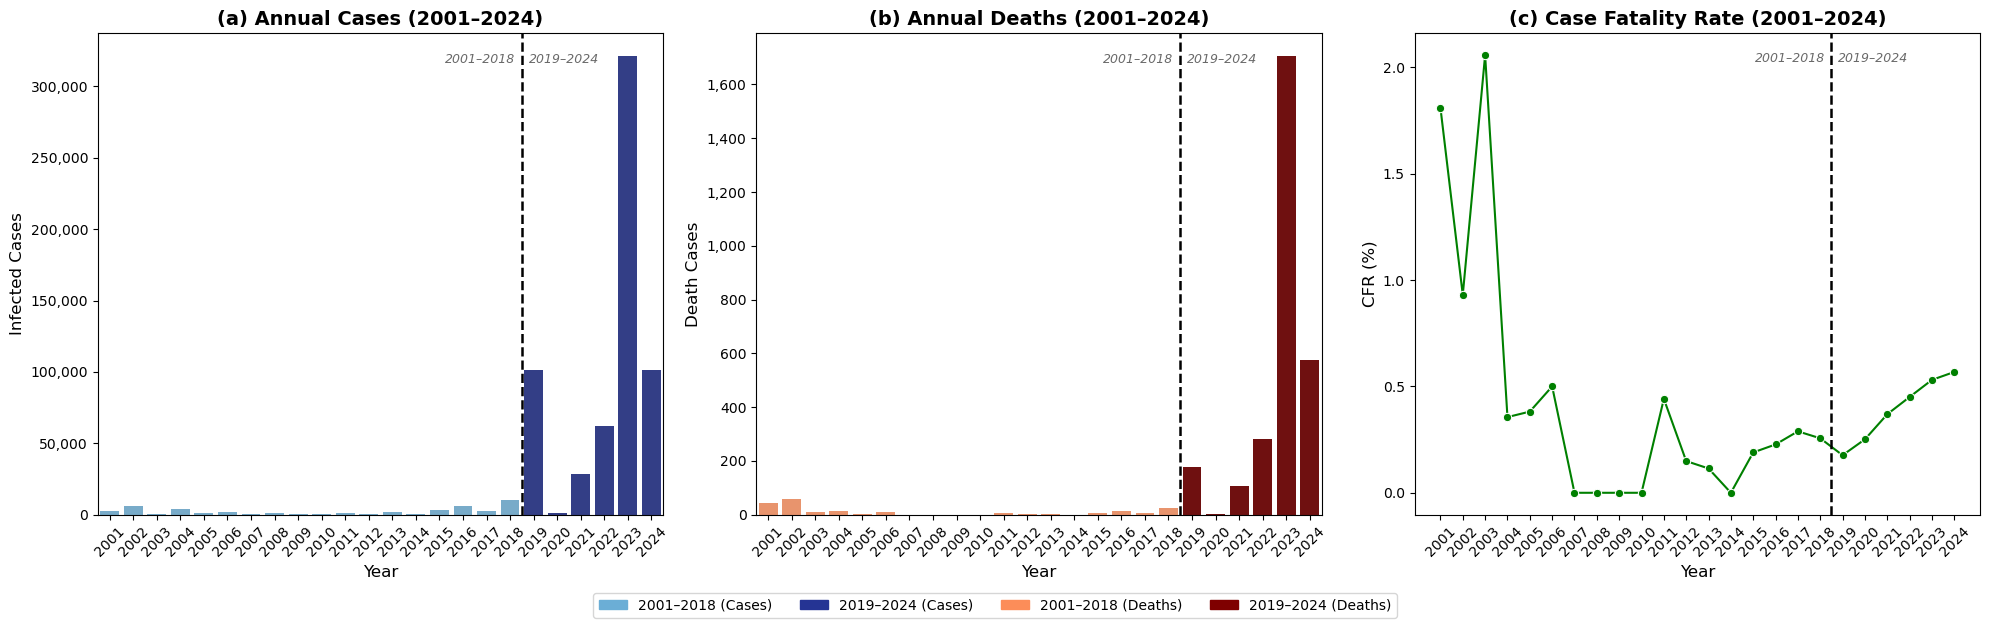

Saved: figure2_dengue_trends.png


In [24]:
"""
Figure 2: Trend of DENV outbreaks in Bangladesh (2001–2024)

Merges data_epidemic (2001–2018) and data_endemic (2019–2024) into 3 panels:
  (a) Annual Infected Cases
  (b) Annual Death Cases
  (c) Case Fatality Rate (CFR)

Each panel shares a single y-axis across both periods.
A vertical dashed line separates the two time groups.
X-axis shows integer years only (no decimals).
"""

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ── Load data ──────────────────────────────────────────────────────────────────
data = pd.read_excel("./data/Dengue_2001-2024.xlsx")

# ── Split into periods ─────────────────────────────────────────────────────────
# FIX 1: Work on explicit copies to avoid SettingWithCopyWarning
data_epidemic = data[data['Year'] <= 2018].copy()
data_endemic  = data[data['Year'] >  2018].copy()

# FIX 2: Calculate CFR on the copies (safe, no slice assignment warning)
data_epidemic['CFR'] = (data_epidemic['Death'] / data_epidemic['Infected']) * 100
data_endemic['CFR']  = (data_endemic['Death']  / data_endemic['Infected'])  * 100

# ── Merge both periods ─────────────────────────────────────────────────────────
# FIX 3: Use drop=True in reset_index() to avoid a duplicate index column
#         appearing as an extra unwanted column after concat
df_epidemic = data_epidemic.reset_index(drop=True).copy()
df_endemic  = data_endemic.reset_index(drop=True).copy()
df_epidemic['Period'] = '2001-2018'
df_endemic['Period']  = '2019-2024'

df_all = pd.concat([df_epidemic, df_endemic], ignore_index=True)

# FIX 4: Keep Year as string for seaborn categorical x-axis (prevents decimal
#         labels like 2002.5) but sort numerically, not lexicographically
df_all['Year'] = df_all['Year'].astype(int).astype(str)
sorted_years   = sorted(df_all['Year'].unique(), key=lambda y: int(y))
n_epidemic     = len(df_epidemic)

# ── Per-year colour palettes ───────────────────────────────────────────────────
# FIX 5: Keys must be strings to match df_all['Year'] dtype
palette_infected = {yr: ('#6baed6' if int(yr) <= 2018 else '#253494') for yr in sorted_years}
palette_deaths   = {yr: ('#fc8d59' if int(yr) <= 2018 else '#7f0000') for yr in sorted_years}

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Panel (a): Infected Cases ──────────────────────────────────────────────────
sns.barplot(
    data=df_all, x='Year', y='Infected',
    hue='Year', palette=palette_infected,
    order=sorted_years, legend=False,
    ax=axes[0]
)
axes[0].set_title('(a) Annual Cases (2001–2024)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Infected Cases', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

# ── Panel (b): Death Cases ─────────────────────────────────────────────────────
sns.barplot(
    data=df_all, x='Year', y='Death',
    hue='Year', palette=palette_deaths,
    order=sorted_years, legend=False,
    ax=axes[1]
)
axes[1].set_title('(b) Annual Deaths (2001–2024)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Death Cases', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

# ── Panel (c): CFR ─────────────────────────────────────────────────────────────
sns.lineplot(
    data=df_all, x='Year', y='CFR',
    marker='o', color='green',
    ax=axes[2]
)
axes[2].set_title('(c) Case Fatality Rate (2001–2024)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Year', fontsize=12)
axes[2].set_ylabel('CFR (%)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)
# axes[2].grid(True, linestyle='--', alpha=0.5)

# ── Divider line + period labels on all panels ─────────────────────────────────
# FIX 6: divider_pos is consistent for both barplot and lineplot because both
#         use the same categorical string x-axis ordered by sorted_years.
#         The divider sits between index n_epidemic-1 (last 2018) and n_epidemic (2019).
divider_pos = n_epidemic - 0.5

for ax in axes:
    ymin, ymax = ax.get_ylim()
    ax.axvline(x=divider_pos, color='black', linewidth=1.8,
               linestyle='--', zorder=5)
    ax.text(divider_pos - 0.3, ymax * 0.96, "2001–2018",
            ha='right', va='top', fontsize=9, color='dimgray', style='italic')
    ax.text(divider_pos + 0.3, ymax * 0.96, "2019–2024",
            ha='left',  va='top', fontsize=9, color='dimgray', style='italic')

# ── Legend ─────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color='#6baed6', label='2001–2018 (Cases)'),
    mpatches.Patch(color='#253494', label='2019–2024 (Cases)'),
    mpatches.Patch(color='#fc8d59', label='2001–2018 (Deaths)'),
    mpatches.Patch(color='#7f0000', label='2019–2024 (Deaths)'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.05), frameon=True)

# ── Caption ────────────────────────────────────────────────────────────────────
# caption = (
#     "Fig 2. Trend of DENV outbreaks in Bangladesh (2001–2024). "
#     "Panels show annual infected cases (a), deaths (b), and case fatality rate — CFR % (c). "
#     "The dashed vertical line separates the epidemic period (2001–2018) "
#     "from the endemic period (2019–2024). "
#     "Colour shading distinguishes the two time periods within each bar chart."
# )
caption = ("")
fig.text(0.5, -0.10, caption, ha='center', va='top', fontsize=9,
         style='italic', wrap=True)

plt.tight_layout()
plt.savefig("figure2_dengue_trends.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figure2_dengue_trends.png")

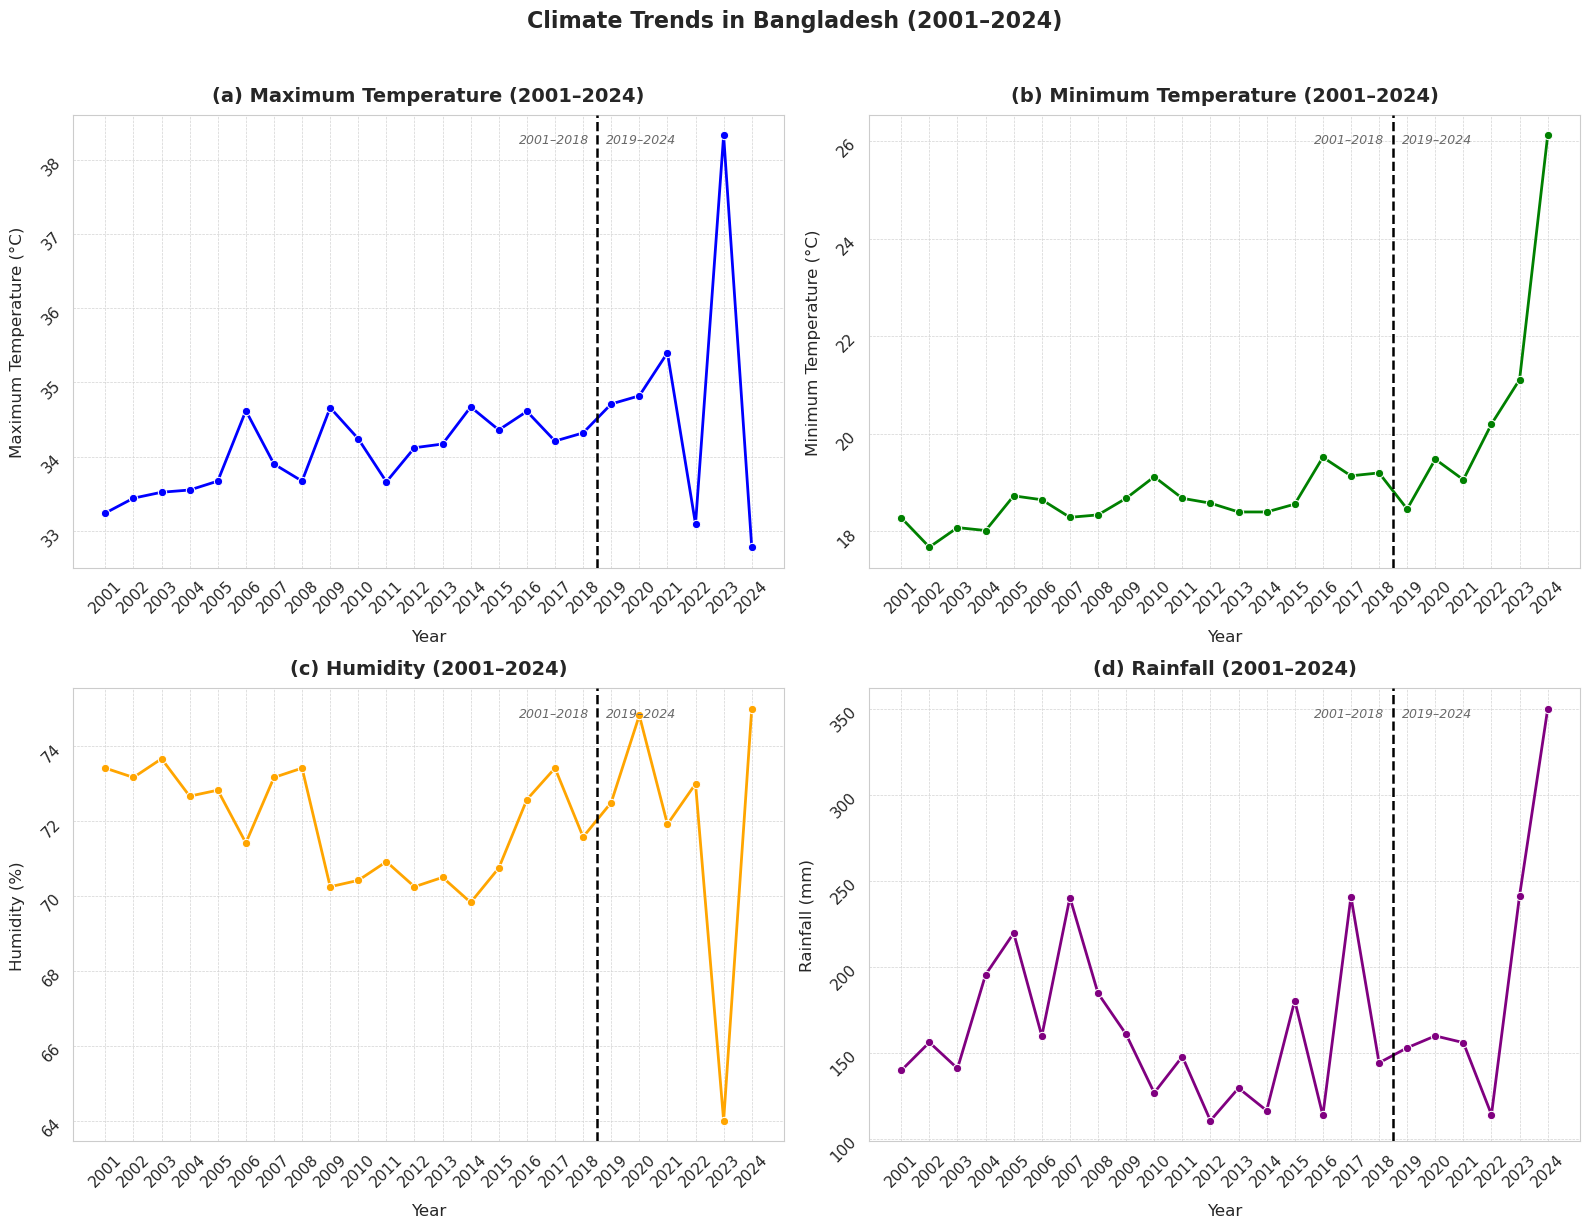

Saved: figure3_climate_trends.png


In [28]:
"""
Figure 3: Climate trends in Bangladesh (2001–2024)

Merges 2001-2018 and 2019-2024 periods into shared y-axis panels:
  (a) Maximum Temperature  — a + e merged
  (b) Minimum Temperature  — b + f merged
  (c) Humidity             — c only (2001-2018), g only (2019-2024) kept separate
  (d) Rainfall             — d + h merged

Layout: 3 merged panels (a, b, d) in top row, humidity panels (c, g) below.
A vertical dashed line at 2019 separates the two time periods.
X-axis shows integer years only.
"""

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

sns.set_style('whitegrid')

# ── Load data ──────────────────────────────────────────────────────────────────
data = pd.read_excel("./data/Dengue_2001-2024.xlsx")

# ── Split and merge ────────────────────────────────────────────────────────────
data_epidemic = data[data['Year'] <= 2018].copy()
data_endemic  = data[data['Year'] >  2018].copy()

df_epidemic = data_epidemic.reset_index(drop=True).copy()
df_endemic  = data_endemic.reset_index(drop=True).copy()
df_epidemic['Period'] = '2001–2018'
df_endemic['Period']  = '2019–2024'

df_all = pd.concat([df_epidemic, df_endemic], ignore_index=True)
df_all['Year'] = df_all['Year'].astype(int).astype(str)
sorted_years = sorted(df_all['Year'].unique(), key=lambda y: int(y))
n_epidemic   = len(df_epidemic)
divider_pos  = n_epidemic - 0.5   # between last 2018 and first 2019

# ── Colour helpers ─────────────────────────────────────────────────────────────
def period_palette(base_light, base_dark):
    return {yr: (base_light if int(yr) <= 2018 else base_dark) for yr in sorted_years}


def add_divider(ax, label_y_frac=0.96):
    """Add vertical dashed divider and period labels."""
    ymin, ymax = ax.get_ylim()
    ax.axvline(x=divider_pos, color='black', linewidth=1.8, linestyle='--', zorder=5)
    ax.text(divider_pos - 0.3, ymin + (ymax - ymin) * label_y_frac,
            "2001–2018", ha='right', va='top', fontsize=9,
            color='dimgray', style='italic')
    ax.text(divider_pos + 0.3, ymin + (ymax - ymin) * label_y_frac,
            "2019–2024", ha='left', va='top', fontsize=9,
            color='dimgray', style='italic')


# ── Figure: 4 merged panels ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Climate Trends in Bangladesh (2001–2024)",
             fontsize=16, fontweight='bold', y=1.02)

# ── Panel (a): Maximum Temperature ────────────────────────────────────────────
sns.lineplot(data=df_all, x='Year', y='Tmax',
             color='blue', marker='o', linewidth=2, ax=axes[0, 0])
axes[0, 0].set_title('(a) Maximum Temperature (2001–2024)', fontsize=14, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Year', fontsize=12, labelpad=10)
axes[0, 0].set_ylabel('Maximum Temperature (°C)', fontsize=12, labelpad=10)
axes[0, 0].tick_params(axis='both', which='major', labelsize=11, rotation=45)
axes[0, 0].grid(color='lightgray', linestyle='--', linewidth=0.5)
add_divider(axes[0, 0])

# ── Panel (b): Minimum Temperature ────────────────────────────────────────────
sns.lineplot(data=df_all, x='Year', y='Tmin',
             color='green', marker='o', linewidth=2, ax=axes[0, 1])
axes[0, 1].set_title('(b) Minimum Temperature (2001–2024)', fontsize=14, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Year', fontsize=12, labelpad=10)
axes[0, 1].set_ylabel('Minimum Temperature (°C)', fontsize=12, labelpad=10)
axes[0, 1].tick_params(axis='both', which='major', labelsize=11, rotation=45)
axes[0, 1].grid(color='lightgray', linestyle='--', linewidth=0.5)
add_divider(axes[0, 1])

# ── Panel (c): Humidity ────────────────────────────────────────────────────────
sns.lineplot(data=df_all, x='Year', y='Relative Humidity',
             color='orange', marker='o', linewidth=2, ax=axes[1, 0])
axes[1, 0].set_title('(c) Humidity (2001–2024)', fontsize=14, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Year', fontsize=12, labelpad=10)
axes[1, 0].set_ylabel('Humidity (%)', fontsize=12, labelpad=10)
axes[1, 0].tick_params(axis='both', which='major', labelsize=11, rotation=45)
axes[1, 0].grid(color='lightgray', linestyle='--', linewidth=0.5)
add_divider(axes[1, 0])

# ── Panel (d): Rainfall ────────────────────────────────────────────────────────
sns.lineplot(data=df_all, x='Year', y='Rainfall',
             color='purple', marker='o', linewidth=2, ax=axes[1, 1])
axes[1, 1].set_title('(d) Rainfall (2001–2024)', fontsize=14, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Year', fontsize=12, labelpad=10)
axes[1, 1].set_ylabel('Rainfall (mm)', fontsize=12, labelpad=10)
axes[1, 1].tick_params(axis='both', which='major', labelsize=11, rotation=45)
axes[1, 1].grid(color='lightgray', linestyle='--', linewidth=0.5)
add_divider(axes[1, 1])

# ── Caption ────────────────────────────────────────────────────────────────────
# caption = (
#     "Figure 3: Climate trends in Bangladesh (2001–2024). "
#     "Panels show maximum temperature (a), minimum temperature (b), humidity (c), and rainfall (d). "
#     "Each panel merges the epidemic period (2001–2018) and endemic period (2019–2024) "
#     "on a shared y-axis. The dashed vertical line separates the two time periods."
# )
caption = ("")
fig.text(0.5, -0.06, caption, ha='center', va='top', fontsize=9,
         style='italic', wrap=True)

plt.tight_layout()
plt.savefig("figure3_climate_trends.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figure3_climate_trends.png")

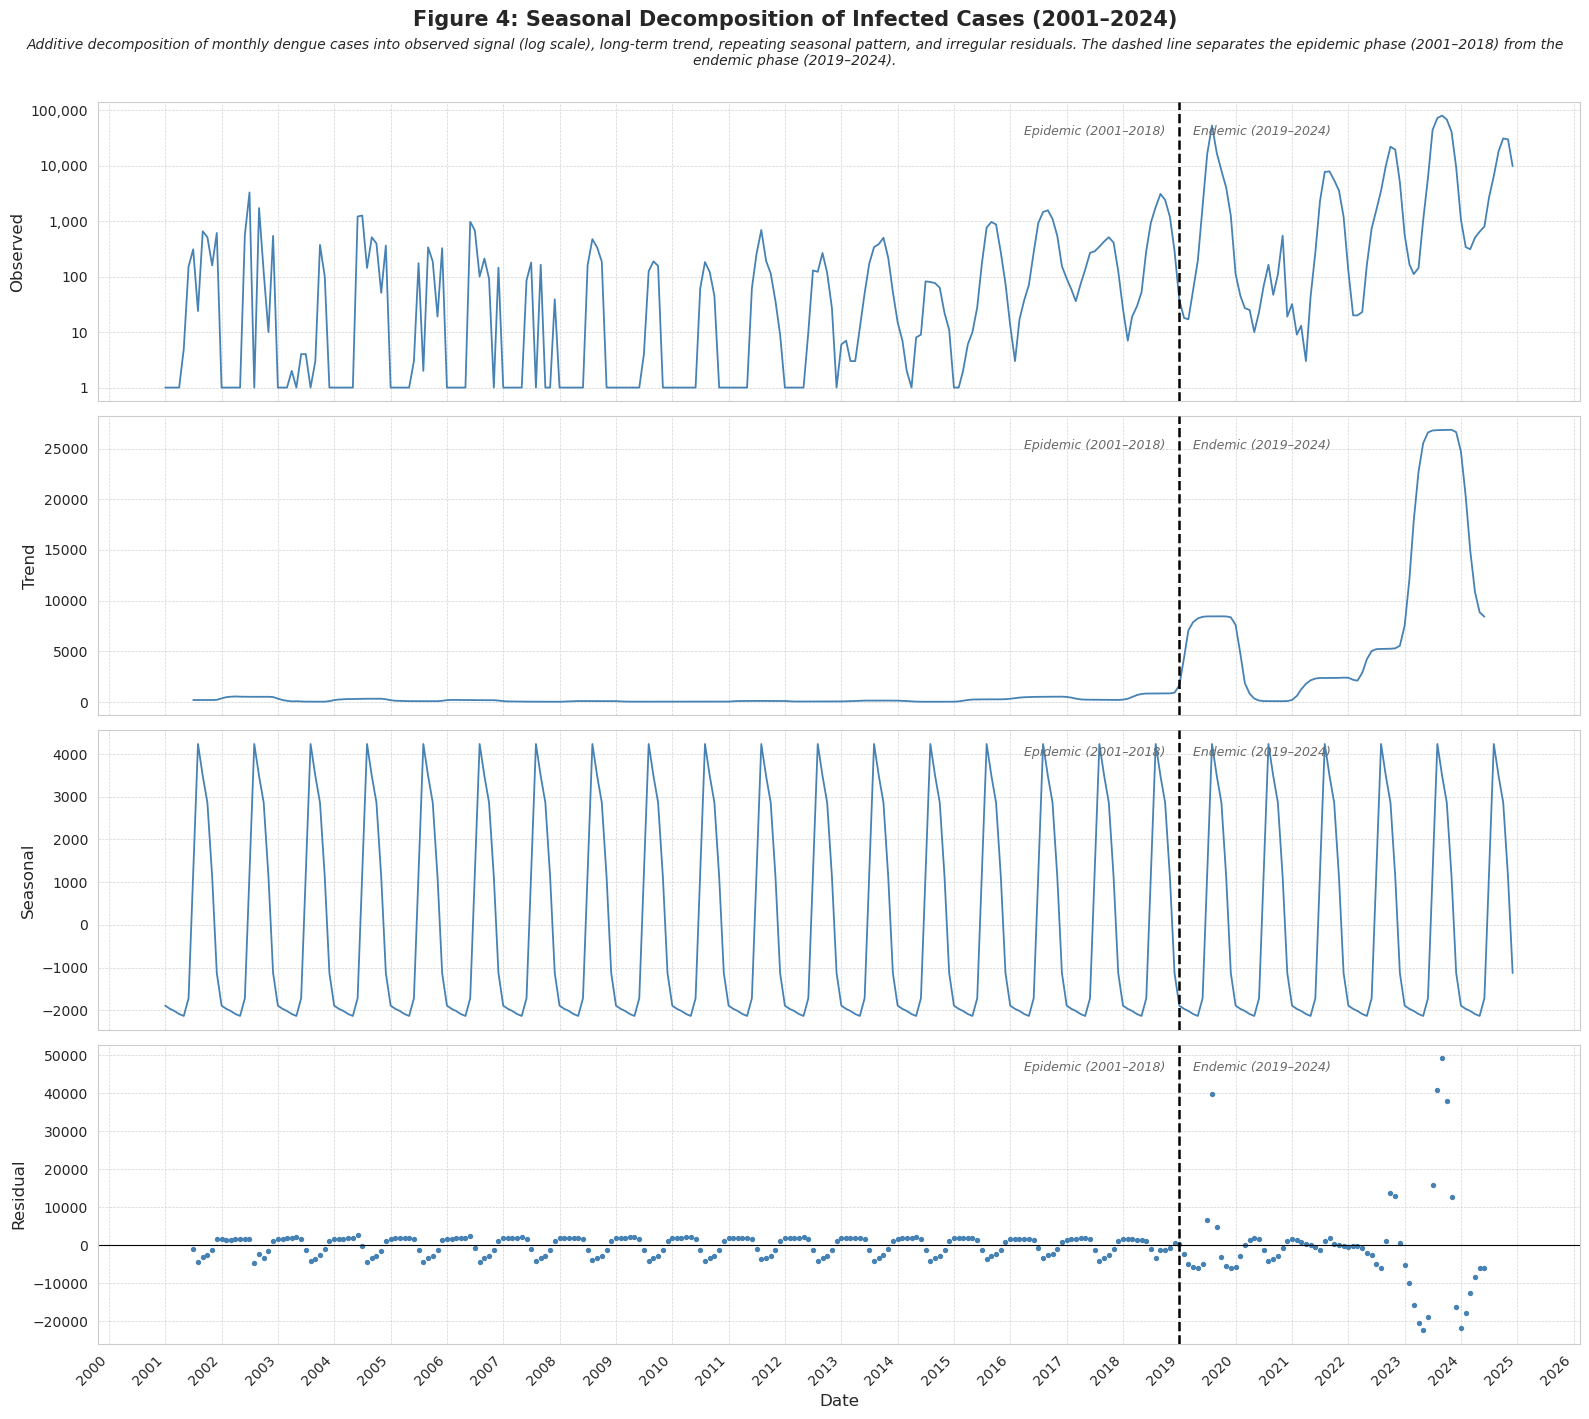

Saved: figure4_seasonal_decomposition.png


In [31]:
"""
Figure 4: Seasonal Decomposition of infected cases (2001–2024)

4 panels (Observed, Trend, Seasonal, Residual) each spanning the full
2001–2024 timeline on a shared y-axis. A vertical dashed line at Jan 2019
separates the epidemic (2001–2018) and endemic (2019–2024) periods.
Observed panel uses log scale.
"""

import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np

# ── Load and reshape ───────────────────────────────────────────────────────────
file_path = "./data/Monthly_Infection_2001-2024.xlsx"
data = pd.read_excel(file_path)

data_long = data.melt(
    id_vars=['Year'],
    value_vars=['January','February','March','April','May','June',
                'July','August','September','October','November','December'],
    var_name='Month', value_name='Cases'
)
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
data_long['Month'] = data_long['Month'].map(month_map)
data_long['Date']  = pd.to_datetime(data_long[['Year','Month']].assign(Day=1))
data_long.sort_values('Date', inplace=True)
data_long = data_long.set_index('Date')

# ── Decompose full series ──────────────────────────────────────────────────────
decomp = seasonal_decompose(data_long['Cases'], model='additive', period=12)

# Divider date
divider = pd.Timestamp('2019-01-01')

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

fig.suptitle(
    "Figure 4: Seasonal Decomposition of Infected Cases (2001–2024)",
    fontsize=15, fontweight='bold', y=1.01
)
fig.text(
    0.5, 0.99,
    "Additive decomposition of monthly dengue cases into observed signal (log scale), "
    "long-term trend, repeating seasonal pattern, and irregular residuals. "
    "The dashed line separates the epidemic phase (2001–2018) from the endemic phase (2019–2024).",
    ha='center', va='top', fontsize=10, style='italic', wrap=True
)

components = [
    ('Observed',  decomp.observed,  'log',    'steelblue', False),
    ('Trend',     decomp.trend,     'linear', 'steelblue', False),
    ('Seasonal',  decomp.seasonal,  'linear', 'steelblue', False),
    ('Residual',  decomp.resid,     'linear', 'steelblue', True),
]

for ax, (label, series, scale, color, is_resid) in zip(axes, components):
    if is_resid:
        ax.scatter(series.index, series.values, s=8, color=color, zorder=2)
        ax.axhline(0, color='black', linewidth=0.8)
    else:
        # For log scale, clip to 1 to avoid log(0)
        plot_series = series.clip(lower=1) if scale == 'log' else series
        ax.plot(plot_series.index, plot_series.values,
                color=color, linewidth=1.3)

    if scale == 'log':
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda v, _: f"{int(v):,}")
        )

    # Vertical divider
    ax.axvline(x=divider, color='black', linewidth=1.8,
               linestyle='--', zorder=5)

    # Period labels
    ymin, ymax = ax.get_ylim()
    y_pos = ymax * 0.92 if scale != 'log' else 10 ** (0.92 * np.log10(max(ymax, 1)))
    ax.text(divider - pd.DateOffset(months=3), y_pos,
            "Epidemic (2001–2018)",
            ha='right', va='top', fontsize=9, color='dimgray', style='italic')
    ax.text(divider + pd.DateOffset(months=3), y_pos,
            "Endemic (2019–2024)",
            ha='left', va='top', fontsize=9, color='dimgray', style='italic')

    ax.set_ylabel(label, fontsize=12)
    ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
    ax.tick_params(axis='both', labelsize=10)

# X-axis formatting — integer years, no decimals
axes[-1].set_xlabel('Date', fontsize=12)
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Caption
# caption = (
#     "Figure 4: Additive seasonal decomposition of monthly dengue infection counts in Bangladesh (2001–2024). "
#     "The observed panel uses a logarithmic y-axis to enable visual comparison across the two periods. "
#     "The dashed vertical line marks the transition from epidemic (2001–2018) to endemic (2019–2024) phase."
# )
caption = ("")
fig.text(0.5, -0.02, caption, ha='center', va='top', fontsize=9,
         style='italic', wrap=True)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("figure4_seasonal_decomposition.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figure4_seasonal_decomposition.png")

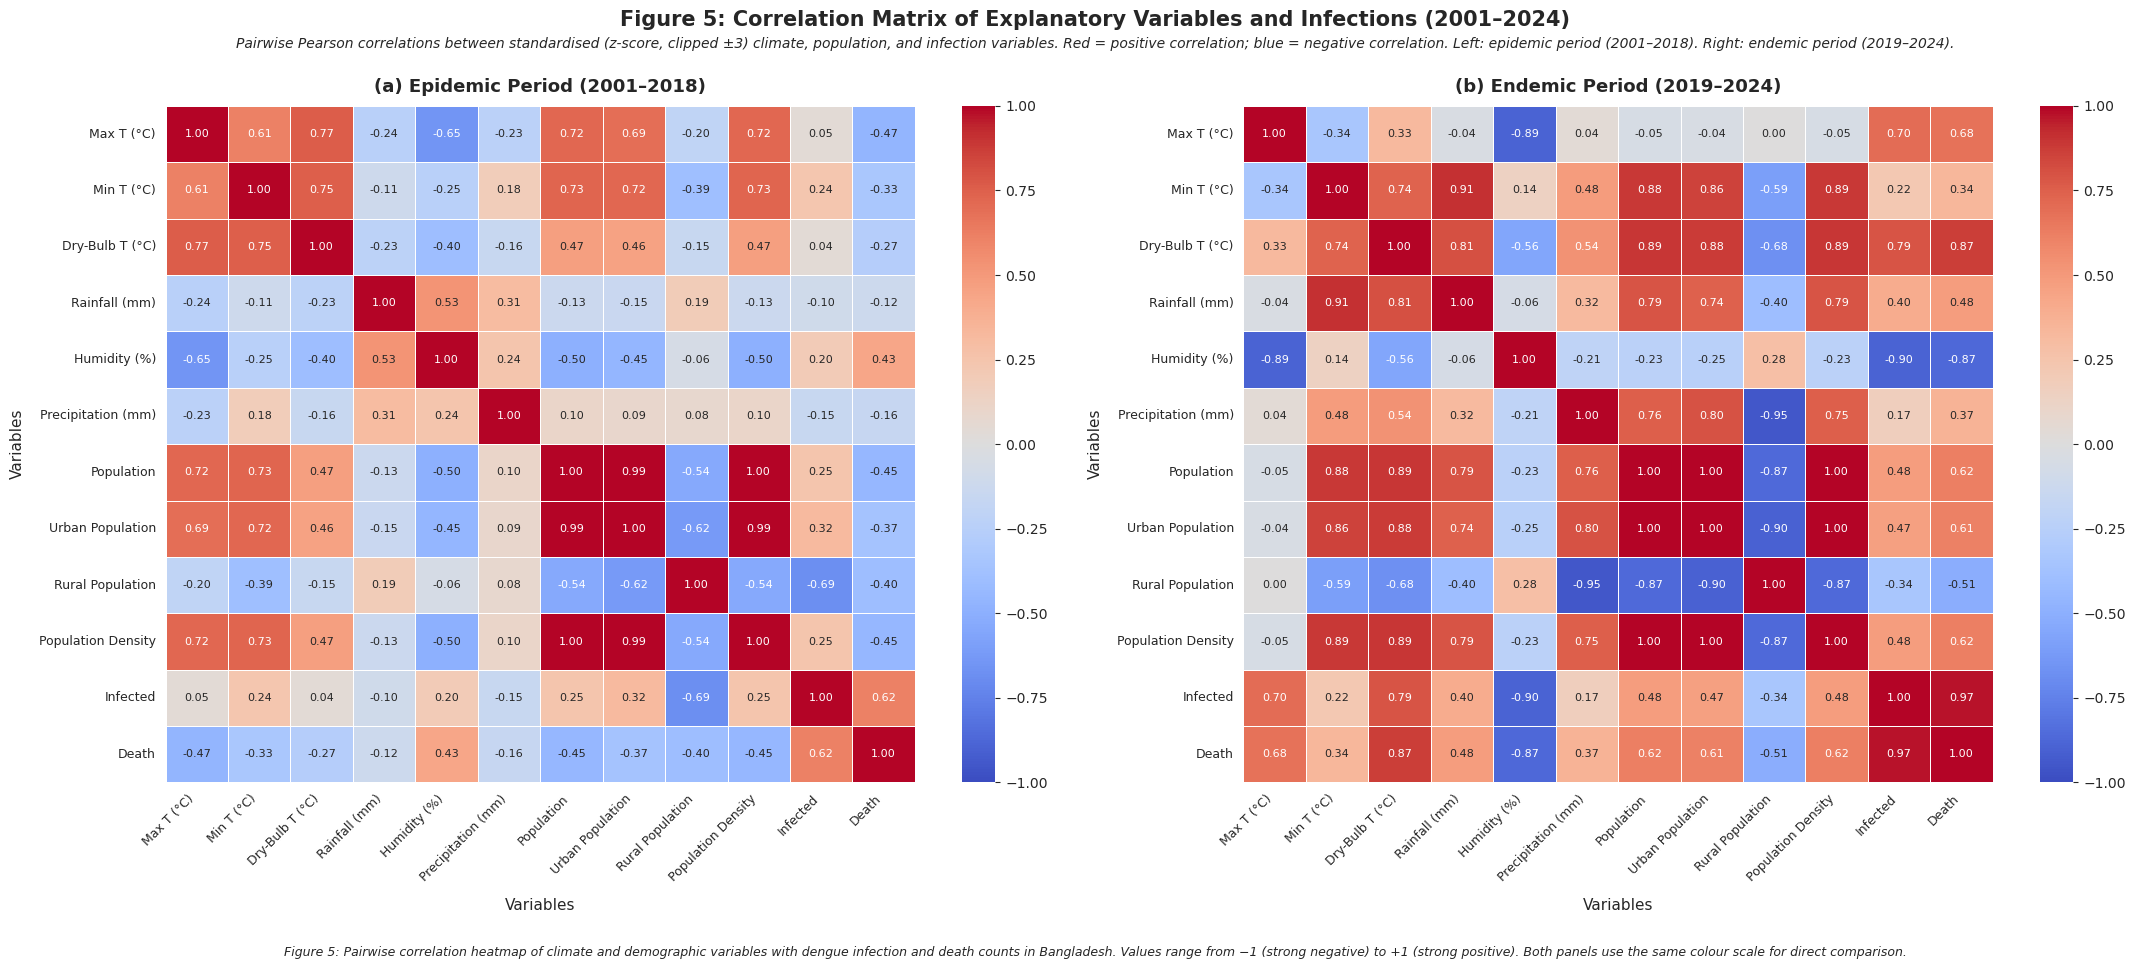

Saved: figure5_correlation_heatmap.png


In [32]:
"""
Figure 5: Correlation heatmap of explanatory variables (2001–2024)

Normalisation matches original code exactly:
  - Standardise (z-score): (x - mean) / std
  - Clip to [-3, 3]
  - Add back Infected and Death (un-normalised) for correlation

Both panels side by side, shared colorbar scale, full x and y axis labels.
"""

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── Load data ──────────────────────────────────────────────────────────────────
data = pd.read_excel("./data/Dengue_2001-2024.xlsx")
data_epidemic = data[data['Year'] <= 2018].copy()
data_endemic  = data[data['Year'] >  2018].copy()

# ── Feature columns (from your original code) ─────────────────────────────────
feature_cols = [
    "Tmax", "Tmin", "Dry Bulb Temperature", "Rainfall",
    "Relative Humidity", "Precipitation",
    "Population", "UPop", "RPop", "Population Density",
]

# ── Axis label map — now includes Population ──────────────────────────────────
axis_label_map = {
    "Tmax":                 "Max T (°C)",
    "Tmin":                 "Min T (°C)",
    "Dry Bulb Temperature": "Dry-Bulb T (°C)",
    "Rainfall":             "Rainfall (mm)",
    "Relative Humidity":    "Humidity (%)",
    "Precipitation":        "Precipitation (mm)",
    "Population":           "Population",
    "UPop":                 "Urban Population",
    "RPop":                 "Rural Population",
    "Population Density":   "Population Density",
    "Infected":             "Infected",
    "Death":                "Death",
}

def make_normalized(df):
    """Standardise, clip, re-attach Infected & Death — matches your original code."""
    norm = df[feature_cols].apply(pd.to_numeric)
    norm = (norm - norm.mean()) / norm.std()   # z-score
    norm = norm.clip(lower=-3, upper=3)         # clip extremes
    norm["Infected"] = df["Infected"].values
    norm["Death"]    = df["Death"].values
    return norm

def make_corr(df):
    norm = make_normalized(df)
    corr = norm.corr()
    corr.rename(index=axis_label_map, columns=axis_label_map, inplace=True)
    return corr

corr_epidemic = make_corr(data_epidemic)
corr_endemic  = make_corr(data_endemic)

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

fig.suptitle(
    "Figure 5: Correlation Matrix of Explanatory Variables and Infections (2001–2024)",
    fontsize=15, fontweight='bold', y=1.02
)
fig.text(
    0.5, 0.99,
    "Pairwise Pearson correlations between standardised (z-score, clipped ±3) climate, "
    "population, and infection variables. "
    "Red = positive correlation; blue = negative correlation. "
    "Left: epidemic period (2001–2018). Right: endemic period (2019–2024).",
    ha='center', va='top', fontsize=10, style='italic', wrap=True
)

heatmap_kw = dict(
    annot=True, cmap="coolwarm", cbar=True,
    fmt=".2f", linewidths=0.5, vmin=-1, vmax=1,
    annot_kws={"size": 8}
)

for ax, corr, title in zip(
    axes,
    [corr_epidemic, corr_endemic],
    ["(a) Epidemic Period (2001–2018)", "(b) Endemic Period (2019–2024)"]
):
    sns.heatmap(corr, ax=ax, **heatmap_kw)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Variables", fontsize=11, labelpad=10)
    ax.set_ylabel("Variables", fontsize=11, labelpad=10)
    # Explicit tick label calls ensure seaborn does not suppress them
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

# ── Caption ────────────────────────────────────────────────────────────────────
fig.text(
    0.5, -0.02,
    "Figure 5: Pairwise correlation heatmap of climate and demographic variables "
    "with dengue infection and death counts in Bangladesh. "
    "Values range from −1 (strong negative) to +1 (strong positive). "
    "Both panels use the same colour scale for direct comparison.",
    ha='center', va='top', fontsize=9, style='italic', wrap=True
)

plt.tight_layout()
plt.savefig("figure5_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figure5_correlation_heatmap.png")

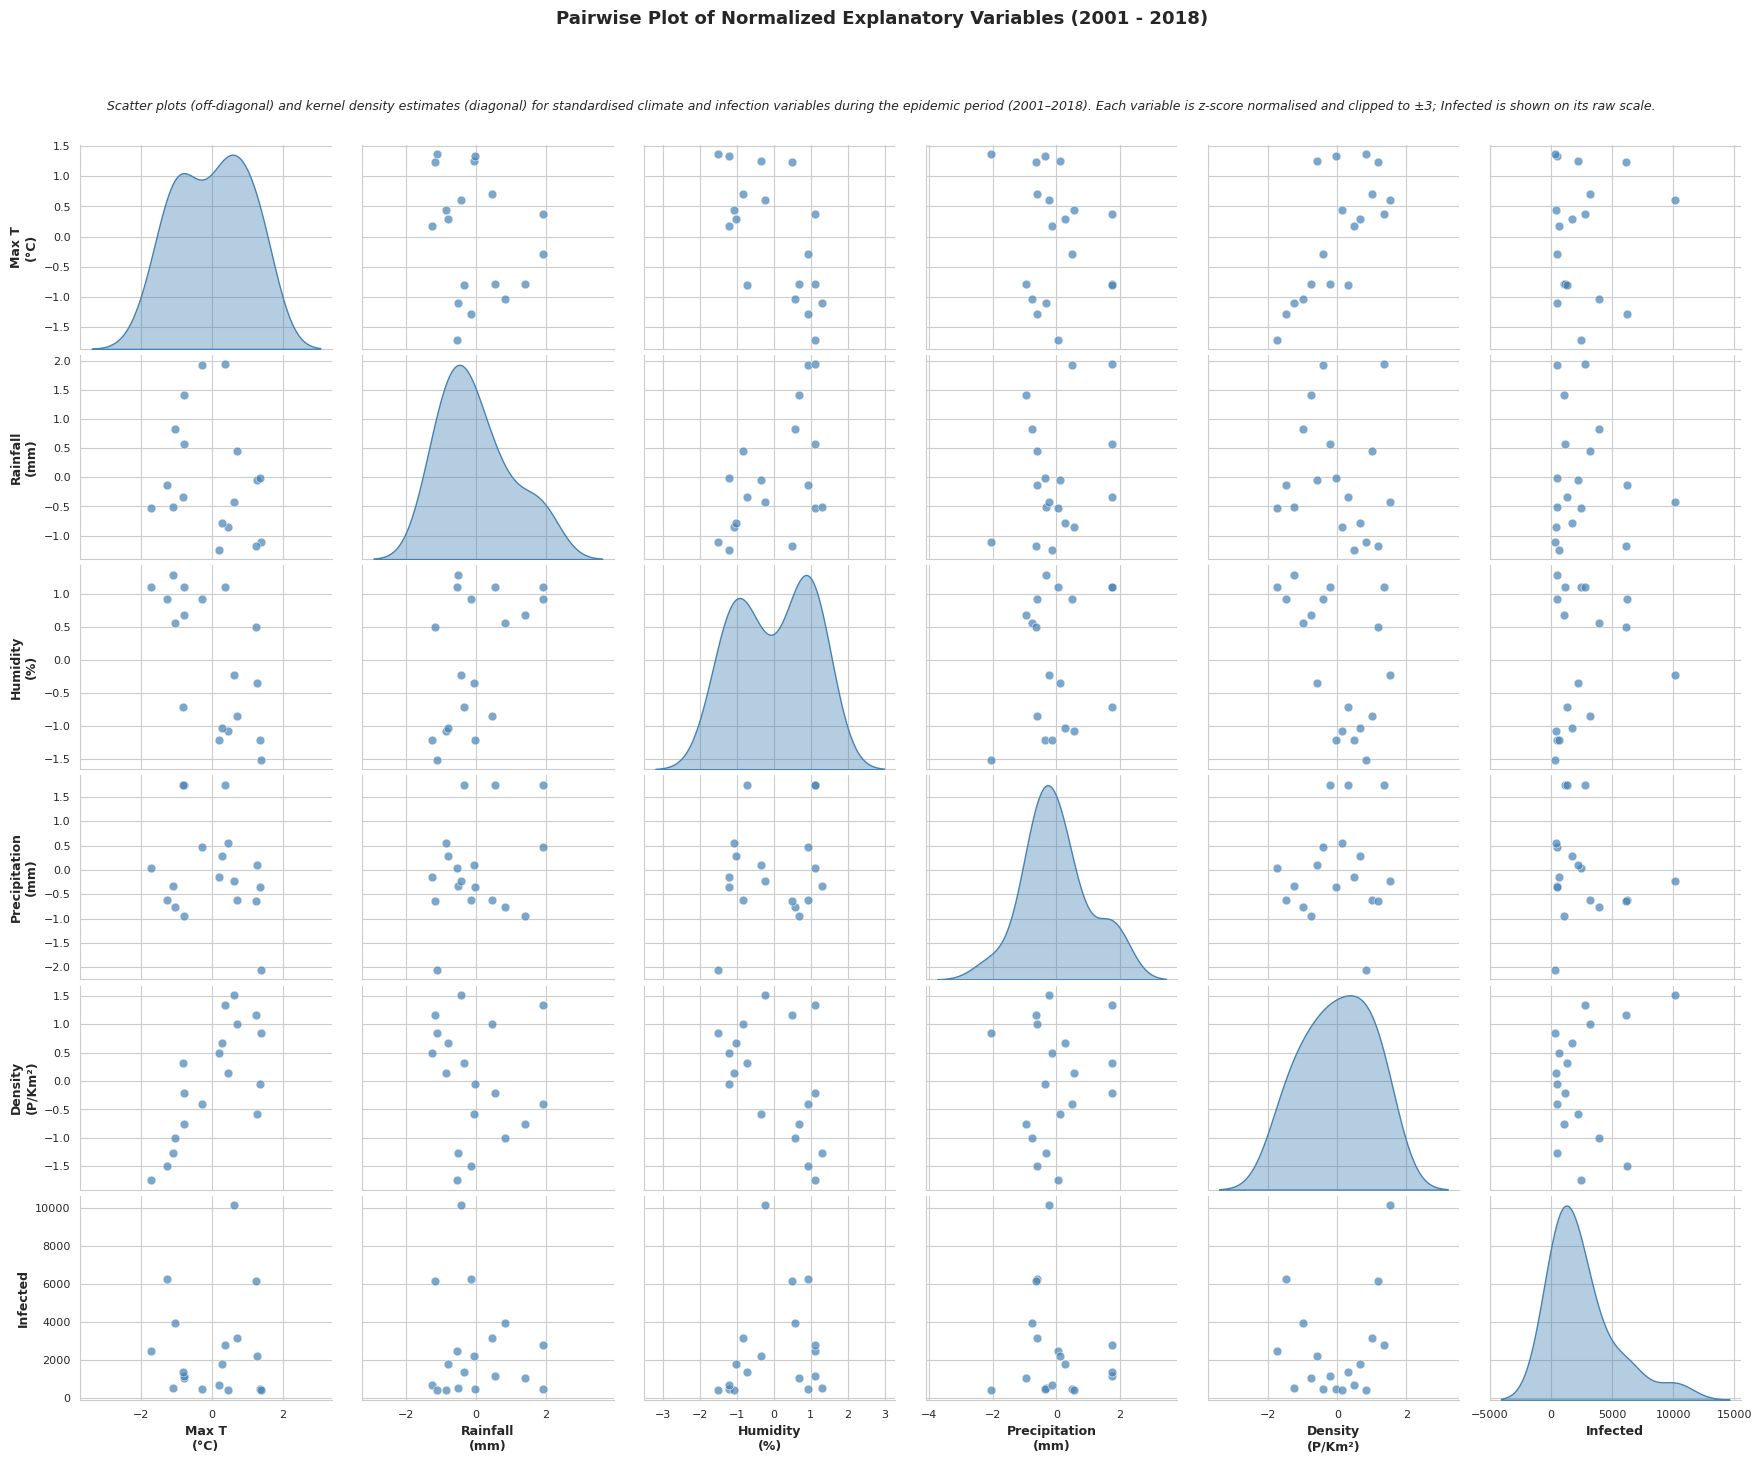

Saved: figure6a_pairplot_epidemic.png


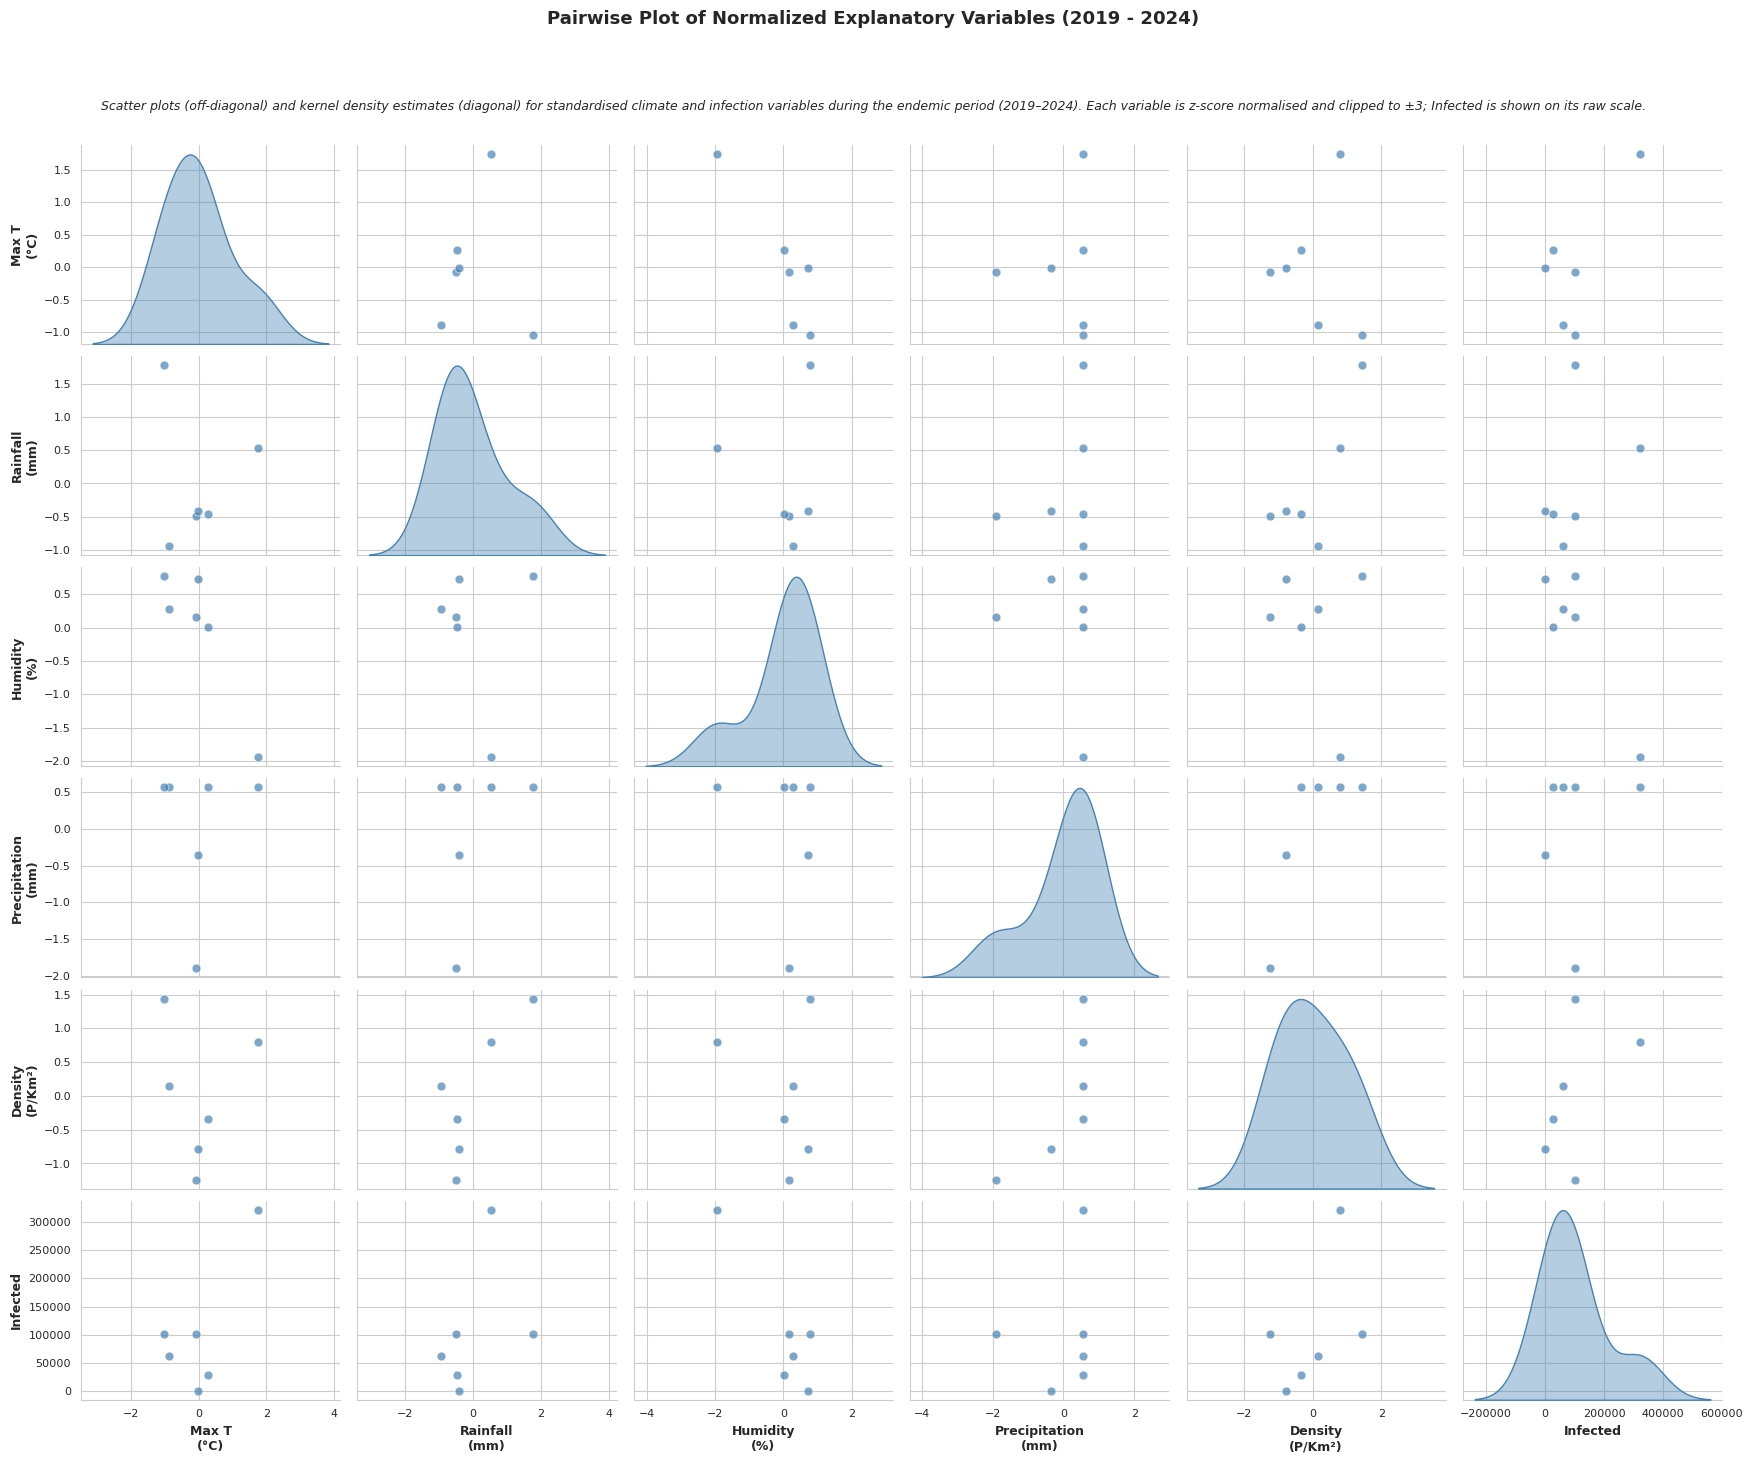

Saved: figure6b_pairplot_endemic.png


In [36]:
"""
Figure 6: Pairwise plot of normalised explanatory variables (2001–2024)

Two separate pairplots — (a) epidemic 2001-2018, (b) endemic 2019-2024 —
saved sequentially. Matches document layout: KDE diagonal, no hue,
subset of variables: Tmax, Rainfall, Relative Humidity, Precipitation,
Population Density, Infected.

Normalisation matches your original code:
  z-score standardisation → clip ±3 → add back Infected raw
"""

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Load data ──────────────────────────────────────────────────────────────────
data = pd.read_excel("./data/Dengue_2001-2024.xlsx")
data_epidemic = data[data['Year'] <= 2018].copy()
data_endemic  = data[data['Year'] >  2018].copy()

# ── Feature columns — subset matching document ─────────────────────────────────
feature_cols = [
    "Tmax", "Rainfall", "Relative Humidity",
    "Precipitation", "Population Density",
]

# ── Axis label map ─────────────────────────────────────────────────────────────
axis_label_map = {
    "Tmax":               "Max T\n(°C)",
    "Rainfall":           "Rainfall\n(mm)",
    "Relative Humidity":  "Humidity\n(%)",
    "Precipitation":      "Precipitation\n(mm)",
    "Population Density": "Density\n(P/Km²)",
    "Infected":           "Infected",
}

def make_normalized(df):
    """Z-score + clip ±3 + re-attach raw Infected — matches your original code."""
    norm = df[feature_cols].apply(pd.to_numeric)
    norm = (norm - norm.mean()) / norm.std()
    norm = norm.clip(lower=-3, upper=3)
    norm["Infected"] = df["Infected"].values
    return norm

def apply_labels(pairplot):
    """Rename axis labels and apply font styling — matches your original code."""
    for ax_row in pairplot.axes:
        for ax in ax_row:
            if ax:
                x_label = ax.get_xlabel()
                y_label = ax.get_ylabel()
                if x_label in axis_label_map:
                    ax.set_xlabel(axis_label_map[x_label])
                if y_label in axis_label_map:
                    ax.set_ylabel(axis_label_map[y_label])
    for ax in pairplot.axes.flatten():
        if ax:
            ax.set_xlabel(ax.get_xlabel(), fontsize=9, fontweight='bold')
            ax.set_ylabel(ax.get_ylabel(), fontsize=9, fontweight='bold')
            ax.tick_params(axis='both', labelsize=8)

def make_pairplot(df, period_label, subtitle, filename):
    norm = make_normalized(df)

    pp = sns.pairplot(
        norm,
        kind='scatter',
        diag_kind='kde',
        height=2.5,
        aspect=1.2,
        plot_kws={'alpha': 0.7, 's': 40, 'color': 'steelblue'},
        diag_kws={'color': 'steelblue', 'fill': True, 'alpha': 0.4},
    )

    apply_labels(pp)

    # Use subplots_adjust to reserve space at the top for title + subtitle
    pp.figure.subplots_adjust(top=0.88)

    # Main title — placed inside the reserved top space
    pp.figure.suptitle(
        period_label,
        fontsize=13, fontweight='bold', y=0.97
    )
    # Explanatory subtitle — one line below the title, inside the figure
    pp.figure.text(
        0.5, 0.91, subtitle,
        ha='center', va='top', fontsize=9, style='italic',
        wrap=True
    )

    pp.figure.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

# ── Panel (a): Epidemic 2001–2018 ─────────────────────────────────────────────
make_pairplot(
    data_epidemic,
    period_label="Pairwise Plot of Normalized Explanatory Variables (2001 - 2018)",
    subtitle=(
        "Scatter plots (off-diagonal) and kernel density estimates (diagonal) for "
        "standardised climate and infection variables during the epidemic period (2001–2018). "
        "Each variable is z-score normalised and clipped to ±3; Infected is shown on its raw scale."
    ),
    filename="figure6a_pairplot_epidemic.png"
)

# ── Panel (b): Endemic 2019–2024 ──────────────────────────────────────────────
make_pairplot(
    data_endemic,
    period_label="Pairwise Plot of Normalized Explanatory Variables (2019 - 2024)",
    subtitle=(
        "Scatter plots (off-diagonal) and kernel density estimates (diagonal) for "
        "standardised climate and infection variables during the endemic period (2019–2024). "
        "Each variable is z-score normalised and clipped to ±3; Infected is shown on its raw scale."
    ),
    filename="figure6b_pairplot_endemic.png"
)